<a href="https://colab.research.google.com/github/abelphilip482-droid/Xapien-Assessment/blob/main/Q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
uploaded = files.upload()

Saving sample_files.zip to sample_files (2).zip


In [4]:
import zipfile, os

zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/data')

for root, dirs, fnames in os.walk('/content/data'):
    level = root.replace('/content/data', '').count(os.sep)
    print('  ' * level + os.path.basename(root) + '/')
    for f in fnames:
        print('  ' * (level+1) + f)

data/
  sample_files/
    sample_output_q1.json
    SUBMISSION_TEMPLATE.md
    evaluation_template_q4.csv
    edge_cases/
      edge_cases_manifest.csv
      person_crossed_arms.jpg
      person_side_pose.jpg
      no_person.jpg
      person_seated.jpg
    test_pairs/
      pairs_manifest.csv
      garment/
        garment_03.jpg
        garment_05.jpg
        garment_04.jpg
        garment_01.jpg
        garment_02.jpg
      person/
        person_05.png
        person_04.png
        person_03.png
        person_02.png
        person_01.png


In [3]:
!pip uninstall -y bitsandbytes -q
!pip install -q transformers accelerate "bitsandbytes>=0.43.0" pillow sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 21.3 MB/s eta 0:00:00


In [6]:
!pip uninstall -y transformers -q
!pip install -q transformers==4.40.0 accelerate==0.30.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.6/302.6 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 118.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
sentence-transformers 5.6.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.


In [9]:
import sys, types, importlib.machinery

fake_flash_attn = types.ModuleType("flash_attn")
fake_flash_attn.__spec__ = importlib.machinery.ModuleSpec("flash_attn", loader=None)
fake_flash_attn.flash_attn_func = None
fake_flash_attn.flash_attn_varlen_func = None
sys.modules["flash_attn"] = fake_flash_attn

fake_interface = types.ModuleType("flash_attn.flash_attn_interface")
fake_interface.__spec__ = importlib.machinery.ModuleSpec("flash_attn.flash_attn_interface", loader=None)
sys.modules["flash_attn.flash_attn_interface"] = fake_interface

print("Stub in place.")

Stub in place.


In [1]:
import torch
from transformers import AutoModel, AutoTokenizer, BitsAndBytesConfig

model_id = "openbmb/MiniCPM-V-2_6"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
)

tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
model = AutoModel.from_pretrained(
    model_id,
    trust_remote_code=True,
    quantization_config=bnb_config,
    attn_implementation="eager",
    torch_dtype=torch.float16,
)
model.eval()
print("Model loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
`low_cpu_mem_usage` was None, now set to True since model is quantized.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Model loaded.


In [3]:
import sys, types, importlib.machinery
import torch
from PIL import Image
from transformers import AutoModel, AutoTokenizer, BitsAndBytesConfig

# stub flash_attn so the import check passes
fake_flash_attn = types.ModuleType("flash_attn")
fake_flash_attn.__spec__ = importlib.machinery.ModuleSpec("flash_attn", loader=None)
fake_flash_attn.flash_attn_func = None
fake_flash_attn.flash_attn_varlen_func = None
sys.modules["flash_attn"] = fake_flash_attn

fake_interface = types.ModuleType("flash_attn.flash_attn_interface")
fake_interface.__spec__ = importlib.machinery.ModuleSpec("flash_attn.flash_attn_interface", loader=None)
sys.modules["flash_attn.flash_attn_interface"] = fake_interface

# free the old model if one is already loaded
if 'model' in dir():
    del model
    torch.cuda.empty_cache()

model_id = "openbmb/MiniCPM-V-2_6"
bnb_config = BitsAndBytesConfig(load_in_8bit=True)

tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
model = AutoModel.from_pretrained(
    model_id,
    trust_remote_code=True,
    quantization_config=bnb_config,
    attn_implementation="sdpa",
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
)
model.eval()
print("Model loaded (8-bit, sdpa).")

# inference test
person_path = '/content/data/sample_files/test_pairs/person/person_01.png'
garment_path = '/content/data/sample_files/test_pairs/garment/garment_01.jpg'

person_img = Image.open(person_path).convert("RGB")
garment_img = Image.open(garment_path).convert("RGB")

prompt = """You are analyzing a person photo and a garment product photo for a virtual try-on pipeline.

Look at BOTH images carefully and respond with ONLY a valid JSON object (no markdown fences, no extra text) in exactly this structure:

{
  "garment_attributes": {
    "type": "<e.g. t-shirt, dress, blouse, jacket>",
    "sleeve_length": "<sleeveless / short / three-quarter / long>",
    "neckline": "<crew / v-neck / collar / scoop / halter / other>",
    "primary_color": "<dominant color>",
    "pattern": "<solid / graphic print / striped / floral / textured / other>"
  },
  "person_attributes": {
    "pose_category": "<front-facing / side / seated>",
    "upper_body_visible": <true/false>,
    "lower_body_visible": <true/false>
  },
  "confidence_notes": "<1-2 sentences on anything occluded, ambiguous, or low-confidence>"
}

Image 1 is the person. Image 2 is the garment. Be precise about pose_category: seated means the person is sitting down, side means the body is turned sideways relative to camera, otherwise front-facing."""

msgs = [{"role": "user", "content": [person_img, garment_img, prompt]}]

with torch.no_grad():
    response = model.chat(
        image=None,
        msgs=msgs,
        tokenizer=tokenizer,
        sampling=False,
        temperature=0.1,
        repetition_penalty=1.2,
        max_new_tokens=512,
    )

print(response)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Model loaded (8-bit, sdpa).


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


{
  "garment_attributes": {
    "type": "t-shirt",
    "sleeve_length": "sleeveless",
    "neckline": "scoop",
    "primary_color": "white",
    "pattern": "solid"
  },
  "person_attributes": {
    "pose_category": "front-facing",
    "upper_body_visible": true,
    "lower_body_visible": true
  },
  "confidence_notes": "The pose category is front-facing, and both the upper and lower body are visible."
}


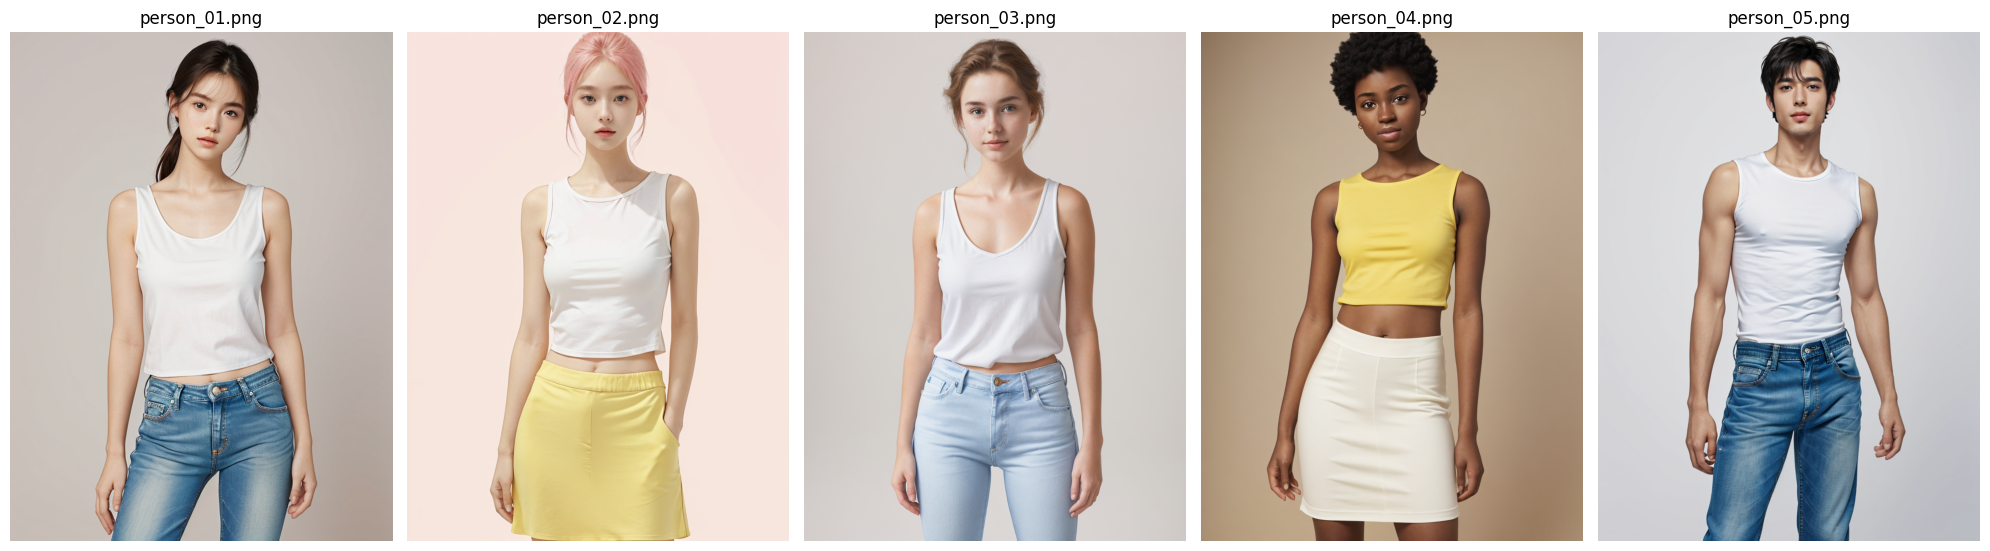

In [20]:
import matplotlib.pyplot as plt
from PIL import Image
import os

PERSON_DIR = '/content/data/sample_files/test_pairs/person'
person_files = sorted(os.listdir(PERSON_DIR))

fig, axes = plt.subplots(1, len(person_files), figsize=(4*len(person_files), 6))

for ax, fname in zip(axes, person_files):
    img = Image.open(os.path.join(PERSON_DIR, fname))
    ax.imshow(img)
    ax.set_title(fname)
    ax.axis('off')

plt.tight_layout()
plt.show()

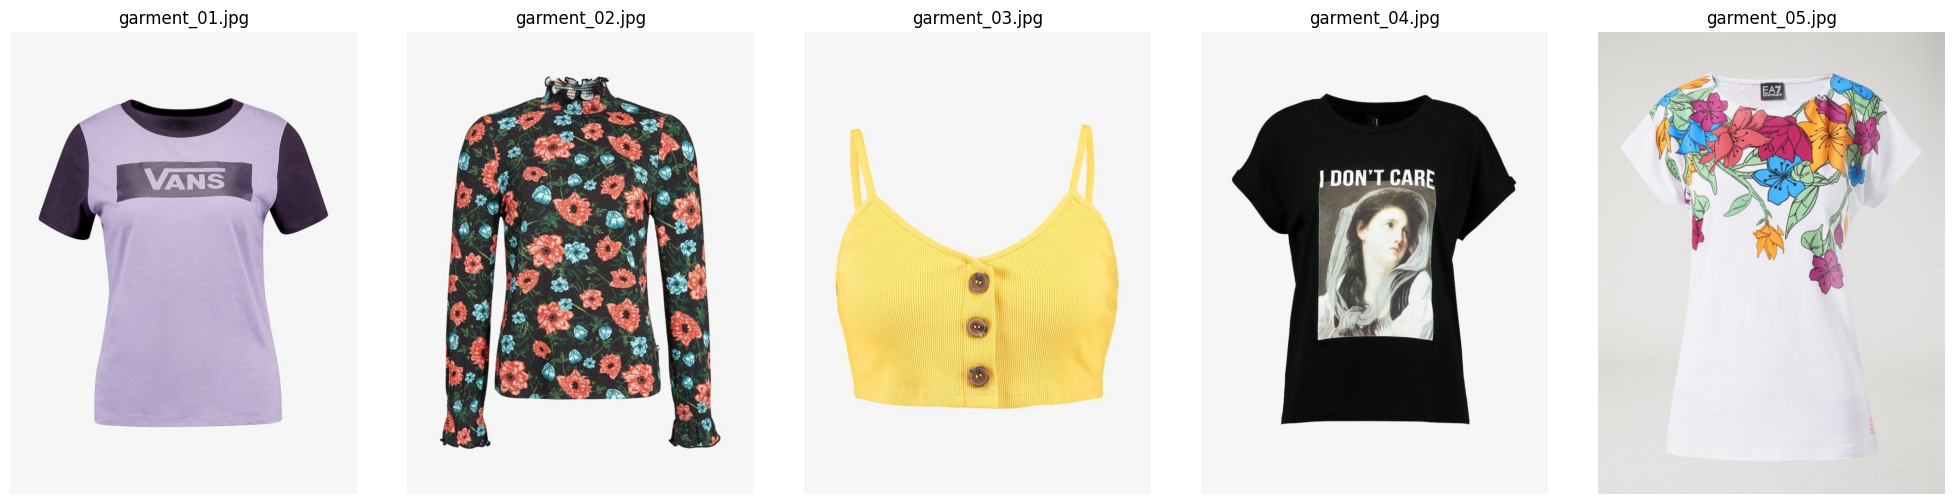

In [19]:
import matplotlib.pyplot as plt
from PIL import Image
import os

GARMENT_DIR = '/content/data/sample_files/test_pairs/garment'
garment_files = sorted(os.listdir(GARMENT_DIR))

fig, axes = plt.subplots(1, len(garment_files), figsize=(4*len(garment_files), 5))

for ax, fname in zip(axes, garment_files):
    img = Image.open(os.path.join(GARMENT_DIR, fname))
    ax.imshow(img)
    ax.set_title(fname)
    ax.axis('off')

plt.tight_layout()
plt.show()

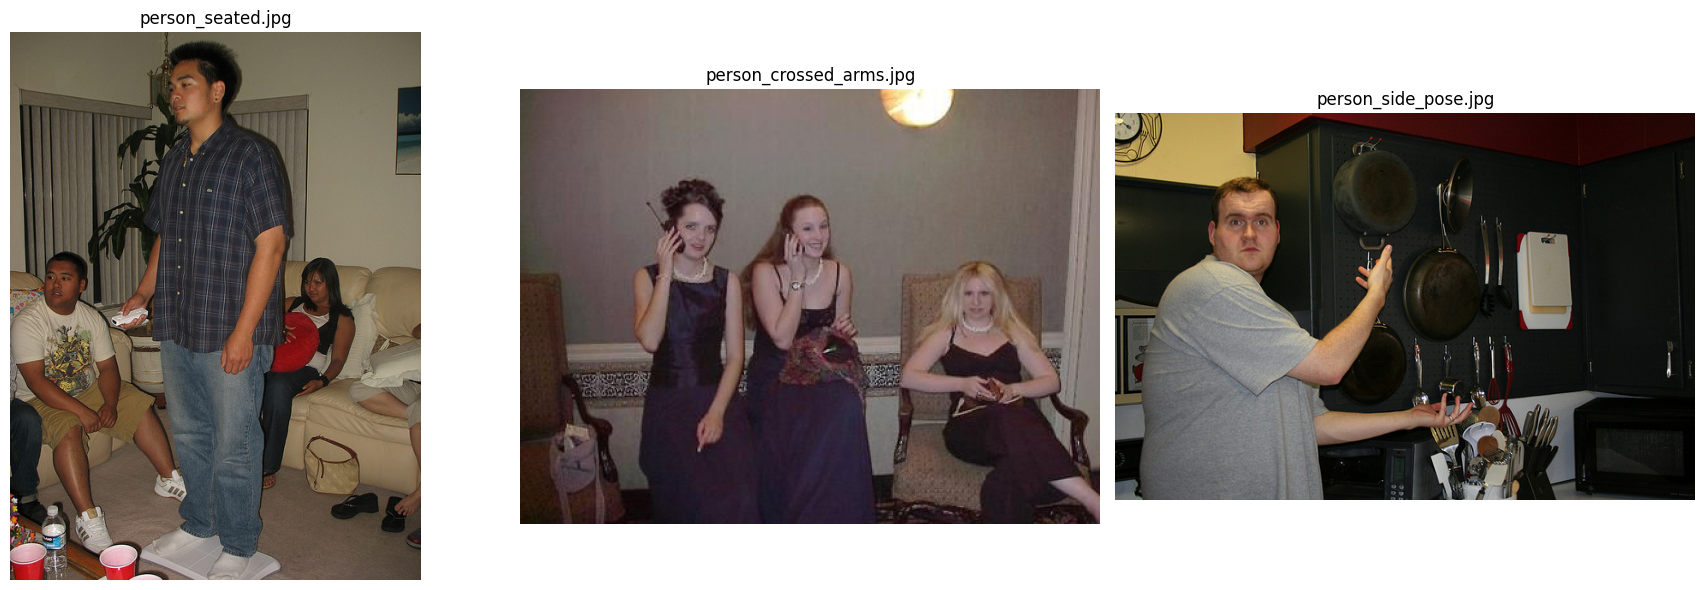

In [15]:
import matplotlib.pyplot as plt
from PIL import Image

fnames = ['person_seated.jpg', 'person_crossed_arms.jpg', 'person_side_pose.jpg']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, fname in zip(axes, fnames):
    img = Image.open(f'/content/data/sample_files/edge_cases/{fname}')
    ax.imshow(img)
    ax.set_title(fname)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [29]:
!pip install -q mediapipe

!wget -q -O /content/pose_landmarker.task https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/latest/pose_landmarker_lite.task
print("Pose landmarker downloaded.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.5/36.5 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 14.3 MB/s eta 0:00:00
Pose landmarker downloaded.


In [30]:
import mediapipe as mp

BaseOptions = mp.tasks.BaseOptions
VisionRunningMode = mp.tasks.vision.RunningMode
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions

pose_options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path='/content/pose_landmarker.task'),
    running_mode=VisionRunningMode.IMAGE
)
landmarker = PoseLandmarker.create_from_options(pose_options)
print("Landmarker loaded.")

Landmarker loaded.


In [31]:
import json, re, os
import numpy as np

PERSON_DIR = '/content/data/sample_files/test_pairs/person'
GARMENT_DIR = '/content/data/sample_files/test_pairs/garment'
EDGE_DIR = '/content/data/sample_files/edge_cases'
OUT_DIR = '/content/data/outputs/q1'
os.makedirs(OUT_DIR, exist_ok=True)

# ---------------- MediaPipe pose classification (deterministic, no VLM) ----------------

def get_landmarks(pil_image):
    image_np = np.array(pil_image.convert("RGB"))
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_np)
    result = landmarker.detect(mp_image)
    if not result.pose_landmarks:
        return None
    return result.pose_landmarks[0]

def classify_pose(landmarks):
    if landmarks is None:
        return "no_person_detected", "No pose landmarks detected."

    LS, RS = landmarks[11], landmarks[12]
    LH, RH = landmarks[23], landmarks[24]
    LK, RK = landmarks[25], landmarks[26]

    hip_vis = min(LH.visibility, RH.visibility)
    knee_vis = min(LK.visibility, RK.visibility)
    hip_y = (LH.y + RH.y) / 2
    knee_y = (LK.y + RK.y) / 2
    knee_hip_delta = knee_y - hip_y
    shoulder_width = abs(LS.x - RS.x)

    if hip_vis > 0.5 and knee_vis > 0.45 and knee_hip_delta < 0.13:
        return "seated", f"Knees close to hip level (delta={knee_hip_delta:.3f})."
    if shoulder_width < 0.20:
        return "side", f"Narrow shoulder span ({shoulder_width:.3f}) indicates rotation."
    return "front-facing", f"Broad shoulder span ({shoulder_width:.3f})."

def visibility_from_landmarks(landmarks):
    if landmarks is None:
        return False, False
    LS, RS = landmarks[11], landmarks[12]
    LH, RH = landmarks[23], landmarks[24]
    LK, RK = landmarks[25], landmarks[26]
    upper = min(LS.visibility, RS.visibility, LH.visibility, RH.visibility) > 0.40
    lower = max(LK.visibility, RK.visibility) > 0.30
    return upper, lower

# ---------------- VLM prompts: single-label for sleeve/color (proven reliable), JSON for the rest ----------------

SLEEVE_PROMPT = """Look at the garment in this image. Classify the sleeve length as exactly ONE of:
sleeveless
short
three-quarter
long

Rules:
- "sleeveless": no sleeve fabric, shoulder/arm bare from the shoulder seam down.
- "short": sleeve fabric covers the upper arm, ending above or around the elbow.
- "three-quarter": sleeve fabric ends between elbow and wrist.
- "long": sleeve fabric extends to the wrist.

Return ONLY one label, nothing else."""

COLOR_PROMPT = """Look ONLY at the garment's fabric in this image - ignore the plain white/gray studio background completely.
What is the single dominant color of the fabric itself? Answer with just one or two words (e.g. "yellow", "purple", "black").
Return ONLY the color, nothing else."""

GARMENT_REST_PROMPT = """Look carefully at this garment image and answer about its type, neckline, and pattern.

IMPORTANT for pattern: check carefully for any print, graphic, logo, text, or floral/textured design on the fabric before deciding. Only answer "solid" if the fabric truly has zero print, logo, or texture anywhere - a plain-colored garment with a printed graphic, logo, or text on it is "graphic print", NOT "solid".

Respond with ONLY a valid JSON object (no markdown fences, no extra text):

{
  "type": "<t-shirt / shirt / tank top / crop top / blouse / dress / other>",
  "neckline": "<crew / v-neck / collar / scoop / halter / other>",
  "pattern": "<solid / graphic print / striped / floral / textured / other>"
}"""

PERSON_VIS_PROMPT = """Look at this person's image. Determine whether their upper body and lower body are visible in frame.
Respond with ONLY valid JSON: {"upper_body_visible": true/false, "lower_body_visible": true/false}"""

def extract_json(raw_text):
    match = re.search(r'\{.*\}', raw_text, re.DOTALL)
    if not match:
        return None, raw_text
    try:
        return json.loads(match.group(0)), None
    except json.JSONDecodeError as e:
        return None, f"parse_error: {e} | raw: {raw_text[:300]}"

def ask_label(images, prompt, max_tokens=20):
    msgs = [{"role": "user", "content": images + [prompt]}]
    with torch.no_grad():
        raw = model.chat(image=None, msgs=msgs, tokenizer=tokenizer,
                          sampling=False, temperature=0.1,
                          repetition_penalty=1.2, max_new_tokens=max_tokens)
    return raw.strip().lower()

def ask_json(images, prompt, max_tokens=300):
    msgs = [{"role": "user", "content": images + [prompt]}]
    with torch.no_grad():
        raw = model.chat(image=None, msgs=msgs, tokenizer=tokenizer,
                          sampling=False, temperature=0.1,
                          repetition_penalty=1.2, max_new_tokens=max_tokens)
    return extract_json(raw)

def num_key(fname):
    m = re.search(r'(\d+)', fname)
    return m.group(1) if m else None

person_files = {num_key(f): f for f in os.listdir(PERSON_DIR) if num_key(f)}
garment_files = {num_key(f): f for f in os.listdir(GARMENT_DIR) if num_key(f)}
results = []

# ---- 5 test pairs ----
for n in sorted(person_files):
    p_path = os.path.join(PERSON_DIR, person_files[n])
    g_path = os.path.join(GARMENT_DIR, garment_files[n])
    p_img = Image.open(p_path).convert("RGB")
    g_img = Image.open(g_path).convert("RGB")

    landmarks = get_landmarks(p_img)
    pose, pose_note = classify_pose(landmarks)
    upper_vis, lower_vis = visibility_from_landmarks(landmarks)

    sleeve = ask_label([g_img], SLEEVE_PROMPT)
    color = ask_label([g_img], COLOR_PROMPT)
    rest, err = ask_json([g_img], GARMENT_REST_PROMPT)

    record = {
        "person_image": person_files[n],
        "garment_image": garment_files[n],
        "garment_attributes": {
            "type": rest.get("type") if rest else None,
            "sleeve_length": sleeve,
            "neckline": rest.get("neckline") if rest else None,
            "primary_color": color,
            "pattern": rest.get("pattern") if rest else None,
        },
        "person_attributes": {
            "pose_category": pose,
            "upper_body_visible": upper_vis,
            "lower_body_visible": lower_vis,
        },
        "confidence_notes": pose_note + (f" | garment parse error: {err}" if err else ""),
        "model_used": "MiniCPM-V-2.6 + MediaPipe Pose Landmarker"
    }
    results.append(record)
    with open(os.path.join(OUT_DIR, f"person_{n}_garment_{n}.json"), 'w') as f:
        json.dump(record, f, indent=2)
    print(f"done: person_{n}_garment_{n}.json  pose={pose}")

# ---- 3 edge-case person images ----
for fname in ['person_side_pose.jpg', 'person_seated.jpg', 'person_crossed_arms.jpg']:
    p_path = os.path.join(EDGE_DIR, fname)
    if not os.path.exists(p_path):
        print(f"skip (not found): {fname}")
        continue
    p_img = Image.open(p_path).convert("RGB")

    landmarks = get_landmarks(p_img)
    pose, pose_note = classify_pose(landmarks)
    upper_vis, lower_vis = visibility_from_landmarks(landmarks)

    record = {
        "person_image": fname,
        "garment_image": None,
        "person_attributes": {
            "pose_category": pose,
            "upper_body_visible": upper_vis,
            "lower_body_visible": lower_vis,
        },
        "confidence_notes": pose_note,
        "model_used": "MiniCPM-V-2.6 + MediaPipe Pose Landmarker"
    }
    results.append(record)
    out_name = f"edge_{fname.replace('.jpg','')}.json"
    with open(os.path.join(OUT_DIR, out_name), 'w') as f:
        json.dump(record, f, indent=2)
    print(f"done: {out_name}  pose={pose}")

print(f"\nTotal: {len(results)} JSON files saved to {OUT_DIR}")

done: person_01_garment_01.json  pose=front-facing
done: person_02_garment_02.json  pose=front-facing
done: person_03_garment_03.json  pose=front-facing
done: person_04_garment_04.json  pose=front-facing
done: person_05_garment_05.json  pose=front-facing
done: edge_person_side_pose.json  pose=side
done: edge_person_seated.json  pose=seated
done: edge_person_crossed_arms.json  pose=seated

Total: 8 JSON files saved to /content/data/outputs/q1


In [32]:
import json, os

pair_files = sorted([f for f in os.listdir('/content/data/outputs/q1') if f.startswith('person_') and 'garment' in f])

for fname in pair_files:
    with open(f'/content/data/outputs/q1/{fname}') as f:
        data = json.load(f)
        print(f"{data.get('garment_image')}:")
        print(json.dumps(data.get('garment_attributes'), indent=2))
        print()

garment_01.jpg:
{
  "type": "t-shirt",
  "sleeve_length": "short",
  "neckline": "crew",
  "primary_color": "purple",
  "pattern": "graphic print"
}

garment_02.jpg:
{
  "type": "blouse",
  "sleeve_length": "long",
  "neckline": "collar",
  "primary_color": "black",
  "pattern": "floral"
}

garment_03.jpg:
{
  "type": "crop top",
  "sleeve_length": "sleeveless",
  "neckline": "v-neck",
  "primary_color": "yellow",
  "pattern": "solid"
}

garment_04.jpg:
{
  "type": "t-shirt",
  "sleeve_length": "short",
  "neckline": "round",
  "primary_color": "black",
  "pattern": "graphic print"
}

garment_05.jpg:
{
  "type": "t-shirt",
  "sleeve_length": "short",
  "neckline": "round",
  "primary_color": "white",
  "pattern": "graphic print"
}

